In [23]:
using NCDatasets, Plots, Dates, Downloads, Statistics, DataFrames, LsqFit

In [24]:
# Load the NetCDF files from the specified directory
data_dir = "datafiles" # Directory to store downloaded NetCDF files
pat = r"^chesapeake_salinity_(\d{8})_t(\d{2})z_n(\d{3})\.nc$" # Regular expression pattern to match the desired NetCDF files
files = filter(f -> occursin(pat, f), readdir(data_dir)) # Filter files in the data directory that match the pattern

# Check if any files were found
if isempty(files)
    error("No files found matching chesapeake_salinity_YYYYMMDD_tCCz_nFFF.nc")
end

# Sort the files based on the date and time extracted from the filename
frames = NamedTuple[]
for f in files
    m = match(pat, f)
    ymd = m.captures[1]
    cyc = parse(Int, m.captures[2])   # cycle hour
    fh  = parse(Int, m.captures[3])   # forecast/nowcast hour
    dt = DateTime(ymd, dateformat"yyyymmdd") + Hour(cyc) + Hour(fh)
    push!(frames, (file="$data_dir/$f", dt=dt))
end
sort!(frames, by = x -> x.dt)

"""
Load surface salinity data from a NetCDF file.

Arguments:
- file: Path to the NetCDF file

Returns:
- lon_valid: Valid longitude values
- lat_valid: Valid latitude values
- salt_valid: Valid salinity values
"""
function load_surface_salinity(file)
    # Open the NetCDF file
    ds = NCDataset(file)

    # Extract latitude, longitude, and surface salinity data
    lon = ds["lon_rho"][:]
    lat = ds["lat_rho"][:]
    salt = ds["salt"][:,:,end,1]
    
    # Close the file
    close(ds)

    # Filter out invalid data (missing values, NaNs, and values greater than 100)
    valid_idx = .!ismissing.(salt) .&& .!isnan.(salt) .&& (salt .< 100)

    # Extract valid longitude, latitude, and salinity values
    if size(lon) == size(valid_idx) && size(lat) == size(valid_idx)
        lon_valid = lon[valid_idx]
        lat_valid = lat[valid_idx]
    elseif ndims(lon) == 1 && length(lon) == length(vec(valid_idx))
        lon2 = reshape(lon, size(valid_idx))
        lat2 = reshape(lat, size(valid_idx))
        lon_valid = lon2[valid_idx]
        lat_valid = lat2[valid_idx]
    else
        lon_valid = vec(lon)[vec(valid_idx)]
        lat_valid = vec(lat)[vec(valid_idx)]
    end

    return lon_valid, lat_valid, Float64.(salt[valid_idx])
end

load_surface_salinity

In [25]:
include("cb_variograms.jl")

Main.Variograms

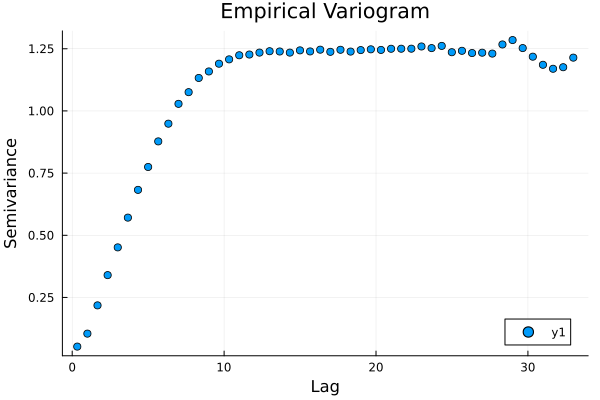

In [26]:
lat_min, lat_max = 37, 37.25
lon_min, lon_max = -76.25, -76.0

# Initialize salinity average variable
sal_avg = nothing

# Load surface salinity data from all frames
for i in 1:length(frames)
    file = frames[i].file

    lon, lat, salt = load_surface_salinity(file)

    roi = (lat .>= lat_min) .&
          (lat .<= lat_max) .&
          (lon .>= lon_min) .&
          (lon .<= lon_max)

    if i == 1
        sal_avg = salt[roi]
    else
        sal_avg = salt[roi] .* 1 ./ i + sal_avg .* (i - 1) ./ i
    end
end

# Store variograms from all frames
all_bins = DataFrame[]

for fr in frames

    lon, lat, salt = load_surface_salinity(fr.file)

    roi = (lat .>= lat_min) .&
          (lat .<= lat_max) .&
          (lon .>= lon_min) .&
          (lon .<= lon_max)

    sal_diff = salt[roi] .- sal_avg

    bins = Variograms.empirical_spatial_variogram(
        lon[roi],
        lat[roi],
        sal_diff
    )

    push!(all_bins, bins)
end

# Lags from first variogram
lags = all_bins[1].h_mid

γ_sum = zeros(length(lags))
pair_count = zeros(Int, length(lags))

for b in all_bins
    for j in eachindex(b.variogram)

        γ = b.variogram[j]
        n = b.count[j]

        if !isnan(γ) && n > 0
            γ_sum[j] += γ * n
            pair_count[j] += n
        end

    end
end

# Weighted empirical variogram
γ_emp = fill(NaN, length(lags))

for j in eachindex(γ_emp)
    if pair_count[j] > 0
        γ_emp[j] = γ_sum[j] / pair_count[j]
    end
end

# Plot empirical variogram
scatter(
    lags,
    γ_emp,
    xlabel = "Lag",
    ylabel = "Semivariance",
    title = "Empirical Variogram"
)

In [27]:
measurement_aggregate = []

for i in 1:length(frames)
    file = frames[i].file

    lon, lat, salt = load_surface_salinity(file)

    roi = (lat .>= lat_min) .& (lat .<= lat_max) .& (lon .>= lon_min) .& (lon .<= lon_max)
    push!(measurement_aggregate, salt[roi])
end

measurement_aggregate = reduce(vcat, measurement_aggregate)

println(mean(measurement_aggregate), " ± ", std(measurement_aggregate))


27.16145692604301 ± 2.4098404831339937


In [28]:
valid = pair_count .> 0

param_fit = curve_fit(
    Variograms.spatio_variogram,
    lags[valid],
    γ_emp[valid],
    pair_count[valid],
    [1.0, 1.0]
)
p = (param_fit.param[1], param_fit.param[2])
y_obs = γ_emp[valid]
y_pred = Variograms.spatio_variogram(lags[valid], p)
ss_res = sum((y_obs .- y_pred).^2)
ss_tot = sum((y_obs .- mean(y_obs)).^2)
r2 = ss_tot == 0 ? NaN : 1 - ss_res / ss_tot
println("R^2 = ", r2)

hp_model = (param_fit.param[1], param_fit.param[2])

println(hp_model)

R^2 = 0.9508473996011241
(1.1450905237045361, 4.9849451903180695)


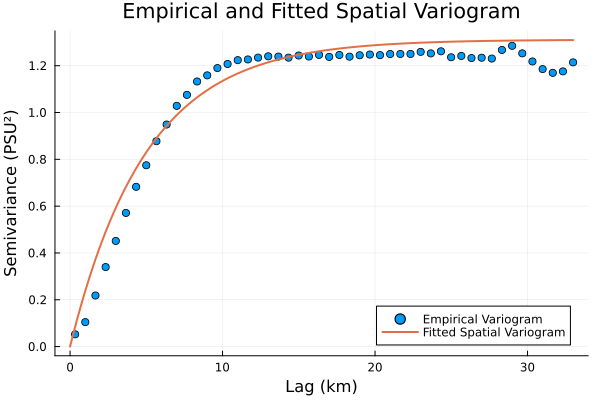

In [29]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.spatio_variogram(lag_grid, hp_model)

scatter(lags, γ_emp,
    label="Empirical Variogram",
    xlabel="Lag (km)",
    ylabel="Semivariance (PSU²)",
    title="Empirical and Fitted Spatial Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Spatial Variogram", lw=2)
savefig("spatial_variogram.png")
plot!()

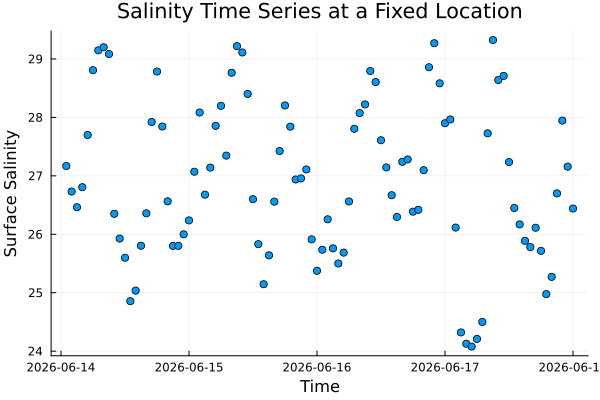

In [30]:
target_lon = (lon_min + lon_max) / 2 - 0.01
target_lat = (lat_min + lat_max) / 2 + 0.01

function nearest_grid_index(lon, lat, target_lon, target_lat)
    d2 = (lon .- target_lon).^2 .+ (lat .- target_lat).^2
    return argmin(d2)
end

lon0, lat0, salt0 = load_surface_salinity(frames[1].file)
idx = nearest_grid_index(lon0, lat0, target_lon, target_lat)

times = DateTime[]
salinity_ts = Float64[]

for fr in frames
    _, _, salt = load_surface_salinity(fr.file)
    val = salt[idx]
    push!(times, fr.dt)
    push!(salinity_ts,
        ismissing(val) || isnan(val) || val >= 100 ? NaN : Float64(val))
end

plot(times, salinity_ts,
    seriestype = :scatter,
    xlabel = "Time",
    ylabel = "Surface Salinity",
    title = "Salinity Time Series at a Fixed Location",
    legend = false
)

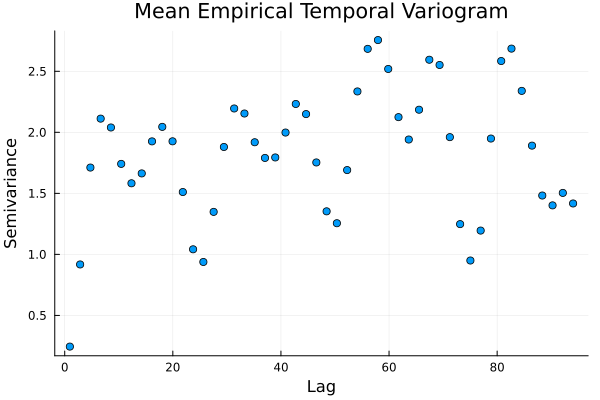

In [32]:
# Load first frame to determine ROI
lon, lat, salt0 = load_surface_salinity(frames[1].file)

roi = findall(
    (lat .>= lat_min) .&
    (lat .<= lat_max) .&
    (lon .>= lon_min) .&
    (lon .<= lon_max)
)

npts = length(roi)
ntimes = length(frames)

# Allocate storage only for ROI
salinity = Matrix{Float64}(undef, ntimes, npts)
times = Vector{DateTime}(undef, ntimes)

# ------------------------------------------------------------------
# Read each file ONCE
# ------------------------------------------------------------------
for (t, fr) in enumerate(frames)

    _, _, salt = load_surface_salinity(fr.file)
    times[t] = fr.dt

    for (k, idx) in enumerate(roi)

        val = salt[idx]

        salinity[t, k] =
            (ismissing(val) || isnan(val) || val >= 100) ?
            NaN : Float64(val)

    end
end

# ------------------------------------------------------------------
# Compute temporal variogram at every ROI location
# ------------------------------------------------------------------
sumγ = nothing
countγ = nothing
lags = nothing

for k in 1:npts

    ts = salinity[:, k]

    valid = .!isnan.(ts)

    if sum(valid) < 2
        continue
    end

    bins = Variograms.empirical_temporal_variogram(
        times[valid],
        ts[valid]
    )

    if sumγ === nothing
        lags = bins.h_mid
        sumγ = zeros(length(bins.variogram))
        countγ = zeros(Int, length(bins.variogram))
    end

    for j in eachindex(bins.variogram)

        γ = bins.variogram[j]

        if !isnan(γ)
            sumγ[j] += γ
            countγ[j] += 1
        end

    end
end

# ------------------------------------------------------------------
# Average empirical variogram
# ------------------------------------------------------------------
γ_mean = sumγ ./ countγ

scatter(
    lags,
    γ_mean,
    xlabel = "Lag",
    ylabel = "Semivariance",
    title = "Mean Empirical Temporal Variogram",
    legend = false
)

In [33]:
param_fit = curve_fit(Variograms.temporal_variogram, lags, γ_mean, [1.0,1.0,1.0]);
hp_temp_model = (param_fit.param[1], param_fit.param[2], param_fit.param[3])
println(hp_temp_model)

valid = .!isnan.(γ_mean)
y_obs = γ_mean[valid]
y_pred = Variograms.temporal_variogram(lags[valid], hp_temp_model)
ss_res = sum((y_obs .- y_pred).^2)
ss_tot = sum((y_obs .- mean(y_obs)).^2)
r2 = ss_tot == 0 ? NaN : 1 - ss_res / ss_tot
println("R^2 = ", r2)

(1.0, 0.016467931241052555, 0.8321994613384603)
R^2 = -0.41156197973391473


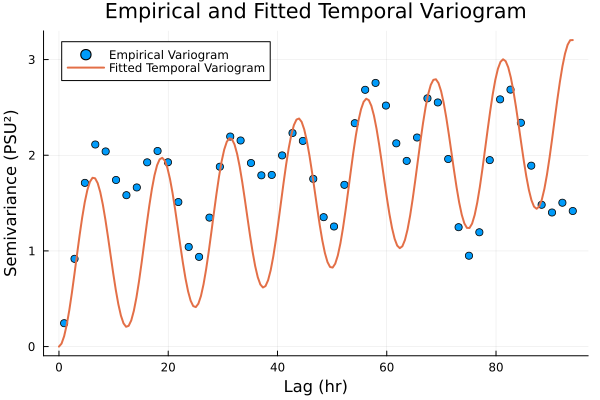

In [34]:
lag_grid = range(0, stop=maximum(lags), length=200)
γ_model = Variograms.temporal_variogram(lag_grid, hp_temp_model)

scatter(lags, γ_mean,
    label="Empirical Variogram",
    xlabel="Lag (hr)",
    ylabel="Semivariance (PSU²)",
    title="Empirical and Fitted Temporal Variogram"
)
plot!(lag_grid, γ_model, label="Fitted Temporal Variogram", lw=2)
savefig("temporal_variogram.png")
plot!()
